<a href="https://colab.research.google.com/github/ValentinaSalamancaGonzalez/Rosalind-Bioinformatics-Solutions/blob/main/Rosalind_String_Algorithms_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#ROSALIND STRING ALGORITHMS 5

#Consensus and profile

#Instructions:
#Finding a Most Likely Common Ancestor
#A matrix is a rectangular table of values divided into rows and columns. An m×n
#matrix has m rows and n columns. Given a matrix A, we write Ai,j to
#indicate the value found at the intersection of row i
#and column j.

#Say that we have a collection of DNA strings, all having the same
#length n. Their profile matrix is a 4×n matrix P, in which P1,j
#represents the number of times that 'A' occurs in the j th position
#of one of the strings, P2,j represents the number of times that C
#occurs in the j th position, and so on.

#A consensus string c is a string of length n formed from our collection
#by taking the most common symbol at each position; the j th symbol of c
#therefore corresponds to the symbol having the maximum value in the j-th
#column of the profile matrix. Of course, there may be more than one
#most common symbol, leading to multiple possible consensus strings.


#Given: A collection of at most 10 DNA strings of equal length (at most 1 kbp) in FASTA format.

#Return: A consensus string and profile matrix for the collection. (If several possible consensus strings exist, then you may return any one of them.)

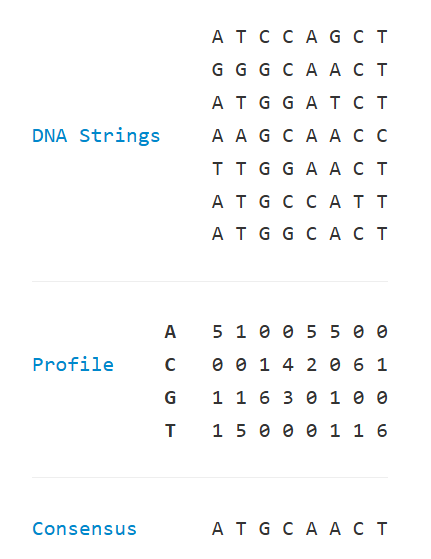

In [17]:
data=open("/content/drive/MyDrive/Rosalind/rosalind_cons (4).txt").read().strip()

# 1. Separate data by newline characters and remove empty lines.
lines = [line.strip() for line in data.split('\n') if line.strip()]

extracted_sequences = []
current_id = ""
current_sequence_lines = []

# 2. Iterate through lines to group DNA sequences by FASTA headers.
for line in lines:
    if line.startswith(">"):
        # If a sequence was previously accumulated, store it before processing
        #the next.
        if current_id:
            extracted_sequences.append(current_id + "\n"
                                       + "".join(current_sequence_lines))
        # Store the new FASTA header and reset the sequence accumulation buffer.
        current_id = line
        current_sequence_lines = []
    else:
        # If the line is part of a sequence, append it to the current
        #sequence buffer.
        current_sequence_lines.append(line)

# Store the last processed record after the loop concludes.
if current_id:
    extracted_sequences.append(current_id + "\n" + "".join(current_sequence_lines))

# 3. Join all processed blocks with newline characters to form the final data
#string.
final_output_data = "\n".join(extracted_sequences)

data = final_output_data

data = data + "\n"
lines = data.split("\n")
extracted_dna_sequences = []

for i in range (0, len(lines)-1):
  line=lines[i]
  if line.startswith(">"):
    n+=1
  else: # For non-header lines, accumulate sequence data.
    extracted_dna_sequences.append(line)
    n+=1

adenine_markers = []
thymine_markers = []
guanine_markers = []
cytosine_markers = []

# Iterate through each extracted DNA sequence and each nucleotide within.
for sequence_index in range(0, len(extracted_dna_sequences)):
  for nucleotide_index in range(0, len(extracted_dna_sequences[sequence_index])):
    if extracted_dna_sequences[sequence_index][nucleotide_index]=="A":
      adenine_markers.append(1)
      thymine_markers.append(0)
      guanine_markers.append(0)
      cytosine_markers.append(0)
    elif extracted_dna_sequences[sequence_index][nucleotide_index]=="T":
      adenine_markers.append(0)
      thymine_markers.append(1)
      guanine_markers.append(0)
      cytosine_markers.append(0)
    elif extracted_dna_sequences[sequence_index][nucleotide_index]=="G":
      adenine_markers.append(0)
      thymine_markers.append(0)
      guanine_markers.append(1)
      cytosine_markers.append(0)
    elif extracted_dna_sequences[sequence_index][nucleotide_index]=="C":
      adenine_markers.append(0)
      thymine_markers.append(0)
      guanine_markers.append(0)
      cytosine_markers.append(1)

# Process for Adenine counts.
i = 0
all_adenine_positions = []
while i < len(adenine_markers):
    fragment = adenine_markers[i:i + len(extracted_dna_sequences[0])]
    all_adenine_positions.append(fragment)
    i += len(extracted_dna_sequences[0])
adenine_profile = [sum(values) for values in zip(*all_adenine_positions)]

# Process for Thymine counts.
i = 0
all_thymine_positions = []
while i < len(thymine_markers):
    fragment = thymine_markers[i:i + len(extracted_dna_sequences[0])]
    all_thymine_positions.append(fragment)
    i += len(extracted_dna_sequences[0])
thymine_profile = [sum(values) for values in zip(*all_thymine_positions)]

# Process for Cytosine counts.
i=0
all_cytosine_positions=[]
while i < len(cytosine_markers):
    fragment = cytosine_markers[i:i + len(extracted_dna_sequences[0])]
    all_cytosine_positions.append(fragment)
    i += len(extracted_dna_sequences[0])
cytosine_profile = [sum(values) for values in zip(*all_cytosine_positions)]

# Process for Guanine counts.
i=0
all_guanine_positions=[]
while i < len(guanine_markers):
    fragment = guanine_markers[i:i + len(extracted_dna_sequences[0])]
    all_guanine_positions.append(fragment)
    i += len(extracted_dna_sequences[0])
guanine_profile = [sum(values) for values in zip(*all_guanine_positions)]

guanine_profile #code used for debugging.

consensus_sequence=[]

# Determine the consensus sequence based on the profile matrices.
for i in range(0, len(adenine_profile)):
  nucleotide_counts_at_position = [adenine_profile[i], cytosine_profile[i],
                                   guanine_profile[i], thymine_profile[i]]
  max_count = max(nucleotide_counts_at_position)
  if adenine_profile[i]==max_count:
    consensus_sequence.append("A")
  elif cytosine_profile[i]==max_count:
    consensus_sequence.append("C")
  elif guanine_profile[i]==max_count:
    consensus_sequence.append("G")
  elif thymine_profile[i]==max_count:
    consensus_sequence.append("T")
consensus_sequence="".join(consensus_sequence)


print(consensus_sequence)
print("A:", (" ".join(map(str, adenine_profile))))
print("C:", (" ".join(map(str, cytosine_profile))))
print("G:", (" ".join(map(str, guanine_profile))))
print("T:", (" ".join(map(str, thymine_profile))))


GTGAAGGATCTACGTCTAGAAACAAGACATGCCGCCTAGTTTGTCGATTATAACTCAGCCGAGCACACAGCATAACCACACAGGGCTAAGGACTCGCACCTCATCAATTGGTCGGTATTGAAATCCTTCACATAACCAATAAGCGGCACAACGCACAACATAGCGTGACACAACAGCTAATCTAATACAACTCGGCAAATGGCAACAGGATGTCGAGGGCAGGATACAGCGATTATACCGACGAGCCACCTATACAACGCCAAAAGAGACGAGATCCGTGGGCTGATGCGGCTGCACAACATCGAATGACGGAATAGCAACCTCTCCAGCCGAAAATCTAAACCGCAATCTCGCACAGGGACTCAAAACGCCCCGCGAGCGTCAATAAACCCTCCCCGGAAGTAGGACGCATCGCGGTGAACTTAAATACTAGTAGTAGCCGCCAGGACCTCATTTAATATCACAGGGTAATGATTGACAGCGTTCAACCCCGTTTGATACGAATGCAATCTTCTCGGTACGATCGGTGAGCAGACAAACCAAAAGCGCCGGTGCAAGCTAGAGCCGCAACTCATACCTCACCACAAGAATCATAACCACAATCCTATCGGCGGAGTCCGAACGTGATGCACCGATACGTTACCCTCAATGATGGTGCAGCAAACCCACCAAATTTAACCACGAGAAAACCAACCCCGACAAAGACATTACAGGGATCAAGATTTATGTGCCGCGAATGGCGCGCGGATTTCAACGCGACGTCTTGATACCATTACGGCATCGGTGTATACGTCCGGGAGTAGCAGATAAAAGTAATACACCACCTCACGCGTGAAATACGATCAAAGTCTCTCCACCGGAATCTCCCCAGACACAGGCAAACCTGCACCCCGGAAGCAGGGACATTGGACAGAAGAG
A: 0 1 2 4 3 2 2 3 1 1 1 5 1 1 3 2 3 3 1 3 4 3 3 5 5 1 4 2 4 2 3 2 3 2 2 1 2 3 2 

In [ ]:
#Now an easier way with biophyton

In [18]:
!pip install biopython

In [19]:
# Import the SeqIO module from Biopython for parsing sequence files.
from Bio import SeqIO

# Define the path to the input FASTA file.
file_path = "/content/drive/MyDrive/Rosalind/rosalind_cons (4).txt"

# Initialize a list to store DNA sequences.
dna_sequences = []

# Parse the FASTA file using SeqIO.parse.
# The 'fasta' format specifier tells Biopython how to interpret the file.
try:
    for record in SeqIO.parse(file_path, "fasta"):
        dna_sequences.append(str(record.seq))
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the path is correct.")
    exit()
except Exception as e:
    print(f"An error occurred while reading the FASTA file: {e}")
    exit()

# Check if any sequences were extracted. If not, there's nothing to process.
if not dna_sequences:
    print("No DNA sequences found in the file.")
else:
    # Determine the length of the sequences. Assuming all sequences are of
    #equal length.
    sequence_length = len(dna_sequences[0])

    # Initialize the profile matrix.
    # This dictionary will store the counts for each nucleotide (A, C, G, T)
    # at each position across all sequences.
    profile_matrix = {
        'A': [0] * sequence_length,
        'C': [0] * sequence_length,
        'G': [0] * sequence_length,
        'T': [0] * sequence_length
    }

    # Populate the profile matrix.
    # Iterate through each DNA sequence.
    for sequence in dna_sequences:
        # Iterate through each nucleotide position in the current sequence.
        for i, nucleotide in enumerate(sequence):
            # Increment the count for the corresponding nucleotide at the
            #current position.
            if nucleotide in profile_matrix:
                profile_matrix[nucleotide][i] += 1

    # Determine the consensus string.
    # This string will represent the most common nucleotide at each position.
    consensus_string_list = []
    # Iterate through each position (column) in the profile matrix.
    for i in range(sequence_length):
        max_count = -1
        most_common_nucleotide = ''
        # Iterate through the nucleotides (A, C, G, T) in a defined order.
        # This ensures consistent selection in case of a tie.
        for nucleotide_type in ['A', 'C', 'G', 'T']:
            # If the current nucleotide's count is greater than the previously
            #found max_count,
            # update max_count and most_common_nucleotide.
            if profile_matrix[nucleotide_type][i] > max_count:
                max_count = profile_matrix[nucleotide_type][i]
                most_common_nucleotide = nucleotide_type
        # Add the most common nucleotide for this position to the consensus list.
        consensus_string_list.append(most_common_nucleotide)

    # Join the list of nucleotides to form the final consensus string.
    consensus_string = "".join(consensus_string_list)

    # Print the consensus string.
    print(consensus_string)

    # Print the profile matrix in the specified format.
    # Iterate through each nucleotide type and print its counts, separated
    #by spaces.
    print("A:", " ".join(map(str, profile_matrix['A'])))
    print("C:", " ".join(map(str, profile_matrix['C'])))
    print("G:", " ".join(map(str, profile_matrix['G'])))
    print("T:", " ".join(map(str, profile_matrix['T'])))


GTGAAGGATCTACGTCTAGAAACAAGACATGCCGCCTAGTTTGTCGATTATAACTCAGCCGAGCACACAGCATAACCACACAGGGCTAAGGACTCGCACCTCATCAATTGGTCGGTATTGAAATCCTTCACATAACCAATAAGCGGCACAACGCACAACATAGCGTGACACAACAGCTAATCTAATACAACTCGGCAAATGGCAACAGGATGTCGAGGGCAGGATACAGCGATTATACCGACGAGCCACCTATACAACGCCAAAAGAGACGAGATCCGTGGGCTGATGCGGCTGCACAACATCGAATGACGGAATAGCAACCTCTCCAGCCGAAAATCTAAACCGCAATCTCGCACAGGGACTCAAAACGCCCCGCGAGCGTCAATAAACCCTCCCCGGAAGTAGGACGCATCGCGGTGAACTTAAATACTAGTAGTAGCCGCCAGGACCTCATTTAATATCACAGGGTAATGATTGACAGCGTTCAACCCCGTTTGATACGAATGCAATCTTCTCGGTACGATCGGTGAGCAGACAAACCAAAAGCGCCGGTGCAAGCTAGAGCCGCAACTCATACCTCACCACAAGAATCATAACCACAATCCTATCGGCGGAGTCCGAACGTGATGCACCGATACGTTACCCTCAATGATGGTGCAGCAAACCCACCAAATTTAACCACGAGAAAACCAACCCCGACAAAGACATTACAGGGATCAAGATTTATGTGCCGCGAATGGCGCGCGGATTTCAACGCGACGTCTTGATACCATTACGGCATCGGTGTATACGTCCGGGAGTAGCAGATAAAAGTAATACACCACCTCACGCGTGAAATACGATCAAAGTCTCTCCACCGGAATCTCCCCAGACACAGGCAAACCTGCACCCCGGAAGCAGGGACATTGGACAGAAGAG
A: 0 1 2 4 3 2 2 3 1 1 1 5 1 1 3 2 3 3 1 3 4 3 3 5 5 1 4 2 4 2 3 2 3 2 2 1 2 3 2 